# Fig. 2: Time Series & PDF Comparison

In [1]:
# ML Code Inspiration from Ashesh Chattopadhyay. Unpublished code. Link: https://colab.research.google.com/drive/1aM0n7kKe80u8coGSiWa6NHr2261bkcB9?usp=sharing
# The code has been heavily augmented and modified to suit our needs, with additional code being added for other purposes.

import numpy as np
from scipy.integrate import solve_ivp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sys
import torch
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast
from torch.nn.parallel import DataParallel
import seaborn as sns
import warnings
from scipy import sparse as sps
from matplotlib import axes
import warnings
import os
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
warnings.filterwarnings("ignore", category=FutureWarning, message=".*.*")

data = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')

data = data[:,1,:]

# Normalization
mean = np.mean(data, axis=0, keepdims=True)
std = np.std(data, axis=0, keepdims=True)
data = (data - mean) / std

# Pre-processing
index = 63
num_variables = 50

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim, num_neurons):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(75, num_neurons)
        self.fc2 = nn.Linear(num_neurons, num_neurons)
        self.fc3 = nn.Linear(num_neurons, num_neurons)
        self.fc4 = nn.Linear(num_neurons, num_neurons)
        self.fc5 = nn.Linear(num_neurons, num_neurons)
        self.fc6 = nn.Linear(num_neurons, num_neurons)
        self.fc_mu = nn.Linear(num_neurons, latent_dim)
        self.fc_logvar = nn.Linear(num_neurons, latent_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + condition_dim, num_neurons)
        self.fc2 = nn.Linear(num_neurons, num_neurons)
        self.fc3 = nn.Linear(num_neurons, num_neurons)
        self.fc4 = nn.Linear(num_neurons, num_neurons)
        self.fc5 = nn.Linear(num_neurons, num_neurons)
        self.fc6 = nn.Linear(num_neurons, num_neurons)
        self.fc_output = nn.Linear(num_neurons, output_dim)

    def forward(self, z, condition):
        z = torch.cat((z, condition), dim=1)  # Concatenate latent vector and condition
        z = torch.relu(self.fc1(z))
        z = torch.relu(self.fc2(z)) + z
        z = torch.relu(self.fc3(z)) + z
        z = torch.relu(self.fc4(z)) + z
        z = torch.relu(self.fc5(z)) + z
        z = torch.relu(self.fc6(z)) + z
        output = self.fc_output(z)
        return output

# Define the VAE model
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim, num_neurons):
        super(ConditionalVAE, self).__init__()
        self.encoder = Encoder(latent_dim, num_neurons)
        self.decoder = Decoder(latent_dim, output_dim, condition_dim, num_neurons)

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z, condition):
        return self.decoder(z, condition)

    def forward(self, x, condition):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z, condition)
        return output, mu, logvar

In [3]:
save_dir        = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/tests/paths"
os.makedirs(save_dir, exist_ok=True)

latent_dim      = 32
output_dim      = 75
condition_dim   = num_variables
num_neurons     = 1024

model_path      = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/best_models_kinda/checkpoint_11"
model           = ConditionalVAE(latent_dim, output_dim, condition_dim, num_neurons).cuda()
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Loading model from checkpoint...")
model.eval()

Loading model from checkpoint...


ConditionalVAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=75, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=1024, bias=True)
    (fc4): Linear(in_features=1024, out_features=1024, bias=True)
    (fc5): Linear(in_features=1024, out_features=1024, bias=True)
    (fc6): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_mu): Linear(in_features=1024, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=82, out_features=1024, bias=True)
    (fc2): Linear(in_features=1024, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=1024, bias=True)
    (fc4): Linear(in_features=1024, out_features=1024, bias=True)
    (fc5): Linear(in_features=1024, out_features=1024, bias=True)
    (fc6): Linear(in_features=1024, out_features=1024, bias=True)
    (fc_outp

In [4]:
timesteps   = 1_000_000
upper_bound = 18.59
lower_bound = 7.41
level       = 63

real_data   = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_3mil.npy")
real_data   = real_data[:timesteps, 1, :]
zonal_wind  = real_data[:, 63]

save        = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/preds/pred_3mil.npy")
save        = save[:timesteps, :]

In [5]:
# Code from (Finkel et al., 2021). Link: https://github.com/justinfocus12/SHORT?tab=readme-ov-file
def first_derivative(F,lower,upper,dz):
    # Compute the first z derivatives any field
    Nt,n = F.shape
    Fz = np.zeros([Nt,n])
    Fz[:,1:-1] = (F[:,2:n] - F[:,0:n-2]) / (2*dz)
    Fz[:,0] = (F[:,1] - lower)/(2*dz)
    Fz[:,-1] = (upper - F[:,-2])/(2*dz)
    return Fz

tau = 0.25
kappa = 0.0
sigma = 1.0
state_dim = 2
dt_sim = 0.0001
obs_dim = 2 # Observable degrees of freedom
ref_alt = 30.0
hB_d = 38.5
physical_params = dict({
    'tau': tau,
    'kappa': kappa,
    'sigma': sigma,
    'state_dim': state_dim,
    'obs_dim': obs_dim,
    'dt_sim': dt_sim,
    'ref_alt': ref_alt,
    'hB_d': hB_d,
    'du_per_day': 1.0,
    'dt_sim': 0.005,
    })

q = {
           'rad': 6370.0e3, 'g': 9.82, 'phi0': np.pi/3, 
           'sx': 2, 'zB_d': 0.0, 'zT_d': 70.0e3, 'H': 7.0e3, 
           'Omega': 2*np.pi/(24*3600), 'Nsq_d': 4.0e-4, 'ideal_gas_constant': 8.314,
           'hB_d': physical_params['hB_d'], 'Nz': 26, 'length': 2.5e5, 'time': 24*3600.0,
           'du_per_day': physical_params['du_per_day'], 'dt_sim': physical_params['dt_sim'],
        }

n = q['Nz']+1 #Number of points including boundaries
q['state_dim'] = 3*(q['Nz']-1)
#Dimensional variables
q['f0_d'] = 2*q['Omega']*np.sin(q['phi0'])
q['k_d'] = q['sx']/(q['rad']*np.cos(q['phi0']))
q['dz_d'] = (q['zT_d']-q['zB_d'])/q['Nz']
q['z_d'] = np.linspace(q['zB_d'],q['zT_d'],q['Nz']+1)
q['Psi0_d'] = q['g']*q['hB_d']/q['f0_d']
q['fn'] = q['f0_d']**2/q['Nsq_d']
#Dimensionless variables
q['Gsq'] = 1.0/(q['length']**2/q['H']**2*q['fn'])
q['k'] = q['k_d']*q['length']
q['dz'] = q['dz_d']/q['H']
q['z'] = q['z_d']/q['H']
q['Psi0'] = q['Psi0_d']*q['time']/q['length']**2
# End of code from (Finkel et al., 2021)

# Computing the integrated heat flux function with code from (Finkel et al., 2021),
# but placing it is a separate function for readability and cohesion.

def ihf_function(data):

    n = q['Nz']-1
    x = data  # Use the 'save' array as 'x'
    Nt = len(x)
    heat_flux = np.ones([Nt,n+1])
    heat_flux *= q['k']

    # Now it has to be multiplied by vertical derivatives
    Xz = first_derivative(x[:,:n],q['Psi0'],0,q['dz']) 
    Yz = first_derivative(x[:,n:2*n],0,0,q['dz'])
    Yz0 = (4*x[:,2*n] - x[:,2*n+1])/(2*q['dz'])
    heat_flux[:,1:] *= (x[:,:n]*Yz - x[:,n:2*n]*Xz)
    heat_flux[:,0] *= q['Psi0']*Yz0
    heat_flux *= np.exp(-q['z'][:-1])
    ihf = np.zeros((Nt,n))
    ihf[:,0] = 0.5*(heat_flux[:,0] + heat_flux[:,1])*q['dz']
    for i in range(1,n):
        ihf[:,i] = ihf[:,i-1] + 0.5*(heat_flux[:,i] + heat_flux[:,i+1])*q['dz']
    
    return ihf

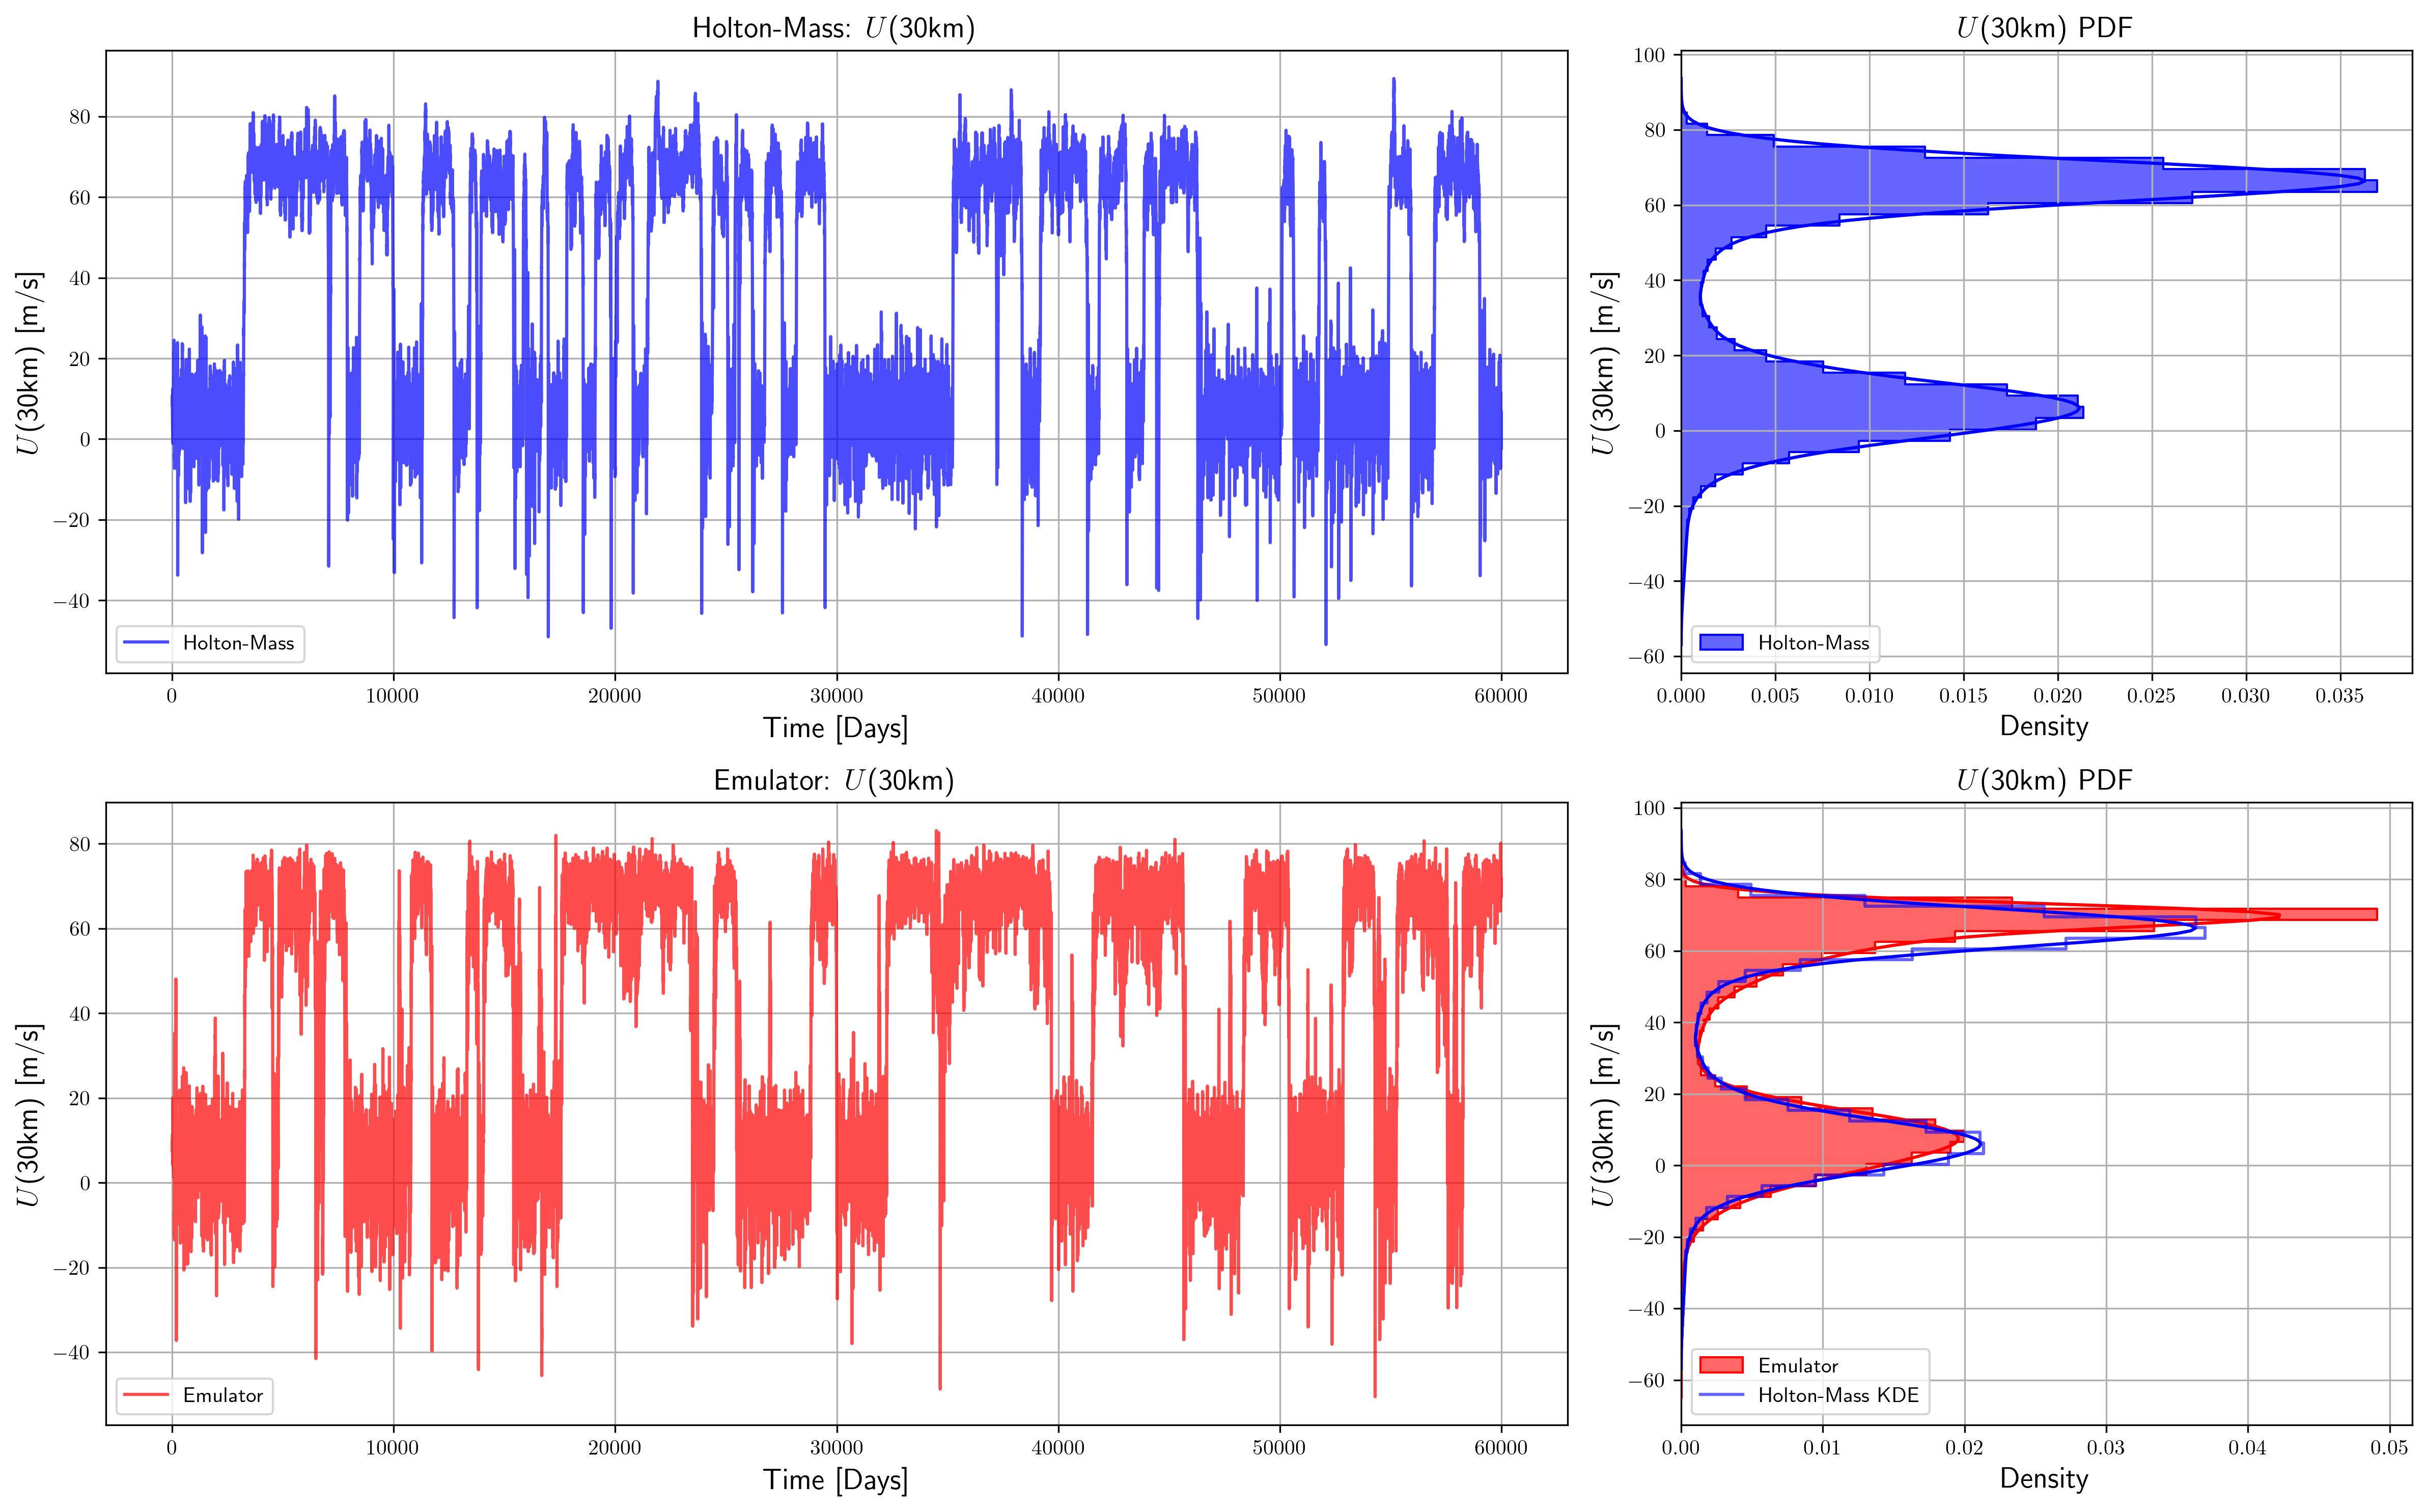

In [6]:
import matplotlib.gridspec as gridspec

# First figure: real time series + histogram overlay
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(nrows=2, ncols=2, width_ratios=[2, 1], height_ratios=[1, 1])
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax00.plot(real_data[:60000, 63] * q['length']/q['time'] , label='Holton-Mass', color='blue', alpha=0.7)
sns.histplot(y = zonal_wind * q['length']/q['time'], bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Holton-Mass', ax=ax01, stat='density')
ax00.set_xlabel(r'Time [Days]', fontsize = 14)
ax00.set_ylabel(r'$U$(30km) [m/s]', fontsize = 14)
ax00.set_title(r'Holton-Mass: $U$(30km)', fontsize = 14)
ax00.legend(loc = 'lower left')
ax00.grid()
ax01.set_xlabel(r'Density', fontsize = 14)
ax01.set_ylabel(r'$U$(30km) [m/s]', fontsize = 14)
ax01.set_title(r'$U$(30km) PDF', fontsize = 14)
ax01.legend(loc = 'lower left')
ax01.grid()


# Second figure: predicted time series + histogram overlay
ax10.plot(save[:60000, 63] * q['length']/q['time'], label='Emulator', color='red', alpha=0.7)
sns.histplot(y = save[:, 63] * q['length']/q['time'], bins=50, kde=True, color='red', alpha=0.6, element='step', label='Emulator', ax=ax11, stat='density')
sns.histplot(y = zonal_wind * q['length']/q['time'], bins=50, kde=True, color='blue', alpha=0.6, element='step', label='Holton-Mass KDE', ax=ax11, fill=False, stat='density')
ax10.set_xlabel(r'Time [Days]', fontsize = 14)
ax10.set_ylabel(r'$U$(30km) [m/s]', fontsize = 14)
ax10.set_title(r'Emulator: $U$(30km)', fontsize = 14)
ax10.legend(loc = 'lower left')
ax10.grid()
ax11.set_xlabel(r'Density', fontsize = 14)
ax11.set_ylabel(r'$U$(30km) [m/s]', fontsize = 14)
ax11.set_title(r'$U$(30km) PDF', fontsize = 14)
ax11.legend(loc= 'lower left')
ax11.grid()
plt.tight_layout()
plt.savefig("/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/plots/final_paper_plots/timeseries_U_30.png")
plt.show()